In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
import math
import itertools as it
from sklearn.preprocessing import power_transform
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

# Credit Card Fraud Dataset - Exploratory Data Analysis

## Loading the Data

In [2]:
data = pd.read_csv('../data/train.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170883 entries, 0 to 170882
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170883 non-null  float64
 1   V1      170883 non-null  float64
 2   V2      170883 non-null  float64
 3   V3      170883 non-null  float64
 4   V4      170883 non-null  float64
 5   V5      170883 non-null  float64
 6   V6      170883 non-null  float64
 7   V7      170883 non-null  float64
 8   V8      170883 non-null  float64
 9   V9      170883 non-null  float64
 10  V10     170883 non-null  float64
 11  V11     170883 non-null  float64
 12  V12     170883 non-null  float64
 13  V13     170883 non-null  float64
 14  V14     170883 non-null  float64
 15  V15     170883 non-null  float64
 16  V16     170883 non-null  float64
 17  V17     170883 non-null  float64
 18  V18     170883 non-null  float64
 19  V19     170883 non-null  float64
 20  V20     170883 non-null  float64
 21  V21     17

The [description](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) of the dataset on Kaggle states that the features V1 - V28 are principal components generated by a PCA, and would therefore hold less interpretable information to do with the credit card transactions themselves. There are no missing values that need to be dealt with, but the Time column can be changed to a timedelta format to more clearly show the time elapsed since the first transaction recorded in the dataset.

In [4]:
data.Time = pd.to_timedelta(data.Time, unit='s')

In [5]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0 days 15:26:31,1.117794,0.256205,0.242660,1.093816,-0.030892,-0.456414,0.271483,-0.167214,-0.189264,...,0.093912,0.306353,-0.120715,0.118219,0.635185,-0.306978,0.029033,0.026853,47.92,0
1,0 days 18:15:55,-1.047459,1.403839,-1.024060,-1.099003,2.132122,3.727823,-1.269340,-1.348829,-1.096401,...,-1.141032,0.466258,0.091116,1.017133,-0.258486,0.285005,-0.053737,0.118632,1.50,0
2,1 days 12:46:34,0.160969,-3.749992,-3.540734,0.424158,-0.901679,-1.154844,1.857496,-0.740155,-1.027584,...,0.625777,0.033529,-1.059404,0.055980,0.303100,-0.320527,-0.234093,0.093084,1052.92,0
3,0 days 09:36:10,1.411564,-1.232946,0.801654,-1.282521,-1.943910,-0.830439,-1.210123,-0.103866,-1.520176,...,-0.260823,-0.510538,0.113410,0.321600,0.106883,-0.334594,0.039047,0.037220,55.00,0
4,0 days 21:07:56,-0.160939,0.705356,1.669306,0.941962,0.324622,-0.080444,0.619046,-0.160557,0.119227,...,-0.230701,-0.331014,-0.123881,-0.170461,-0.418866,-0.544911,0.032649,-0.057032,1.00,0


In [6]:
data.drop(columns=['Time', 'Class']).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
V1,170883.0,0.001683,1.959978,-56.407510,-0.919495,0.021721,1.316299,2.451888
V2,170883.0,0.001754,1.643975,-72.715728,-0.601935,0.064475,0.802718,22.057729
V3,170883.0,-0.001165,1.521113,-33.680984,-0.891556,0.181141,1.027967,9.382558
V4,170883.0,-0.001944,1.417821,-5.683171,-0.852335,-0.023592,0.745195,16.875344
V5,170883.0,-0.001328,1.362528,-42.147898,-0.692613,-0.055282,0.610550,34.801666
V6,170883.0,-0.002825,1.321418,-26.160506,-0.768927,-0.275022,0.396282,22.529298
V7,170883.0,0.000114,1.221464,-43.557242,-0.553805,0.041664,0.570617,36.677268
V8,170883.0,-0.000458,1.202798,-73.216718,-0.208171,0.022892,0.326289,19.587773
V9,170883.0,-0.000277,1.099671,-13.434066,-0.641431,-0.052015,0.598418,15.594995
V10,170883.0,0.003074,1.091705,-24.588262,-0.534050,-0.091303,0.458314,23.745136


In [7]:
data['Class'].value_counts()

Class
0    170588
1       295
Name: count, dtype: int64

Because of the number of records in the dataset, as well as the class imbalance, we will take all of the positive cases for the sample, and then randomly sample negative cases in the ratio $1:5$. 

## Data Visualisation

In [8]:
sample_positive = data[data['Class'] == 1]
sample_negative = data[data['Class'] == 0].sample(n=5*len(sample_positive), random_state=42)

In [9]:
sample = pd.concat([sample_positive, sample_negative])

In [10]:
sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
475,0 days 14:11:52,-9.848776,7.365546,-12.898538,4.273323,-7.611991,-3.427045,-8.350808,6.863604,-2.387567,...,0.931958,-0.874467,-0.192639,-0.035426,0.538665,-0.263934,1.134095,0.225973,99.99,1
4344,0 days 09:59:02,-4.194074,4.382897,-5.118363,4.455230,-4.812621,-1.224645,-7.281328,3.332250,-3.679659,...,1.550473,0.614573,0.028521,0.013704,-0.149512,-0.131687,0.473934,0.473757,14.46,1
4579,0 days 23:51:04,-3.365265,2.928541,-5.660999,3.891160,-1.840375,-1.800887,-5.558679,2.402322,-2.848923,...,0.875260,-0.102501,-0.606283,-0.743165,0.096319,-0.135060,1.238695,0.099824,1.00,1
4811,0 days 11:17:42,-4.446847,-0.014793,-5.126307,6.945130,5.269255,-4.297177,-2.591242,0.342671,-3.880663,...,0.247913,-0.049586,-0.226017,-0.401236,0.856124,0.661272,0.492560,0.971834,1.00,1
4973,0 days 09:05:45,-2.179135,0.020218,-2.182733,2.572046,-3.663733,0.081568,0.268049,0.660437,-2.374027,...,1.026421,0.299614,1.656800,0.328433,0.106457,0.691775,0.196779,0.241085,717.15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138647,1 days 16:09:20,-3.831337,3.297461,-3.123883,-0.465171,-1.183776,-0.860303,-1.312884,2.503885,-0.121089,...,0.350683,0.431774,-0.001878,0.433186,0.187777,0.579827,-1.289346,-0.296591,11.50,0
58466,1 days 17:26:37,2.014089,-0.350840,-0.586754,0.299346,-0.376002,-0.324149,-0.454475,-0.042371,1.339441,...,-0.223100,-0.514089,0.270146,-0.761633,-0.334632,-0.578667,0.031570,-0.036341,18.99,0
34364,1 days 03:13:49,-0.100205,0.881499,1.327876,4.670126,1.380748,0.631774,0.101638,-0.176216,-0.474286,...,-0.473258,-0.826155,0.313039,-0.444798,-2.055560,-0.440054,0.099852,0.049714,14.41,0
71486,0 days 16:28:04,1.117781,0.258177,0.478352,1.006079,-0.143770,-0.205290,0.017800,0.021395,-0.344073,...,0.179080,0.582348,-0.087972,0.263418,0.572429,-0.300932,0.035618,0.013955,14.90,0


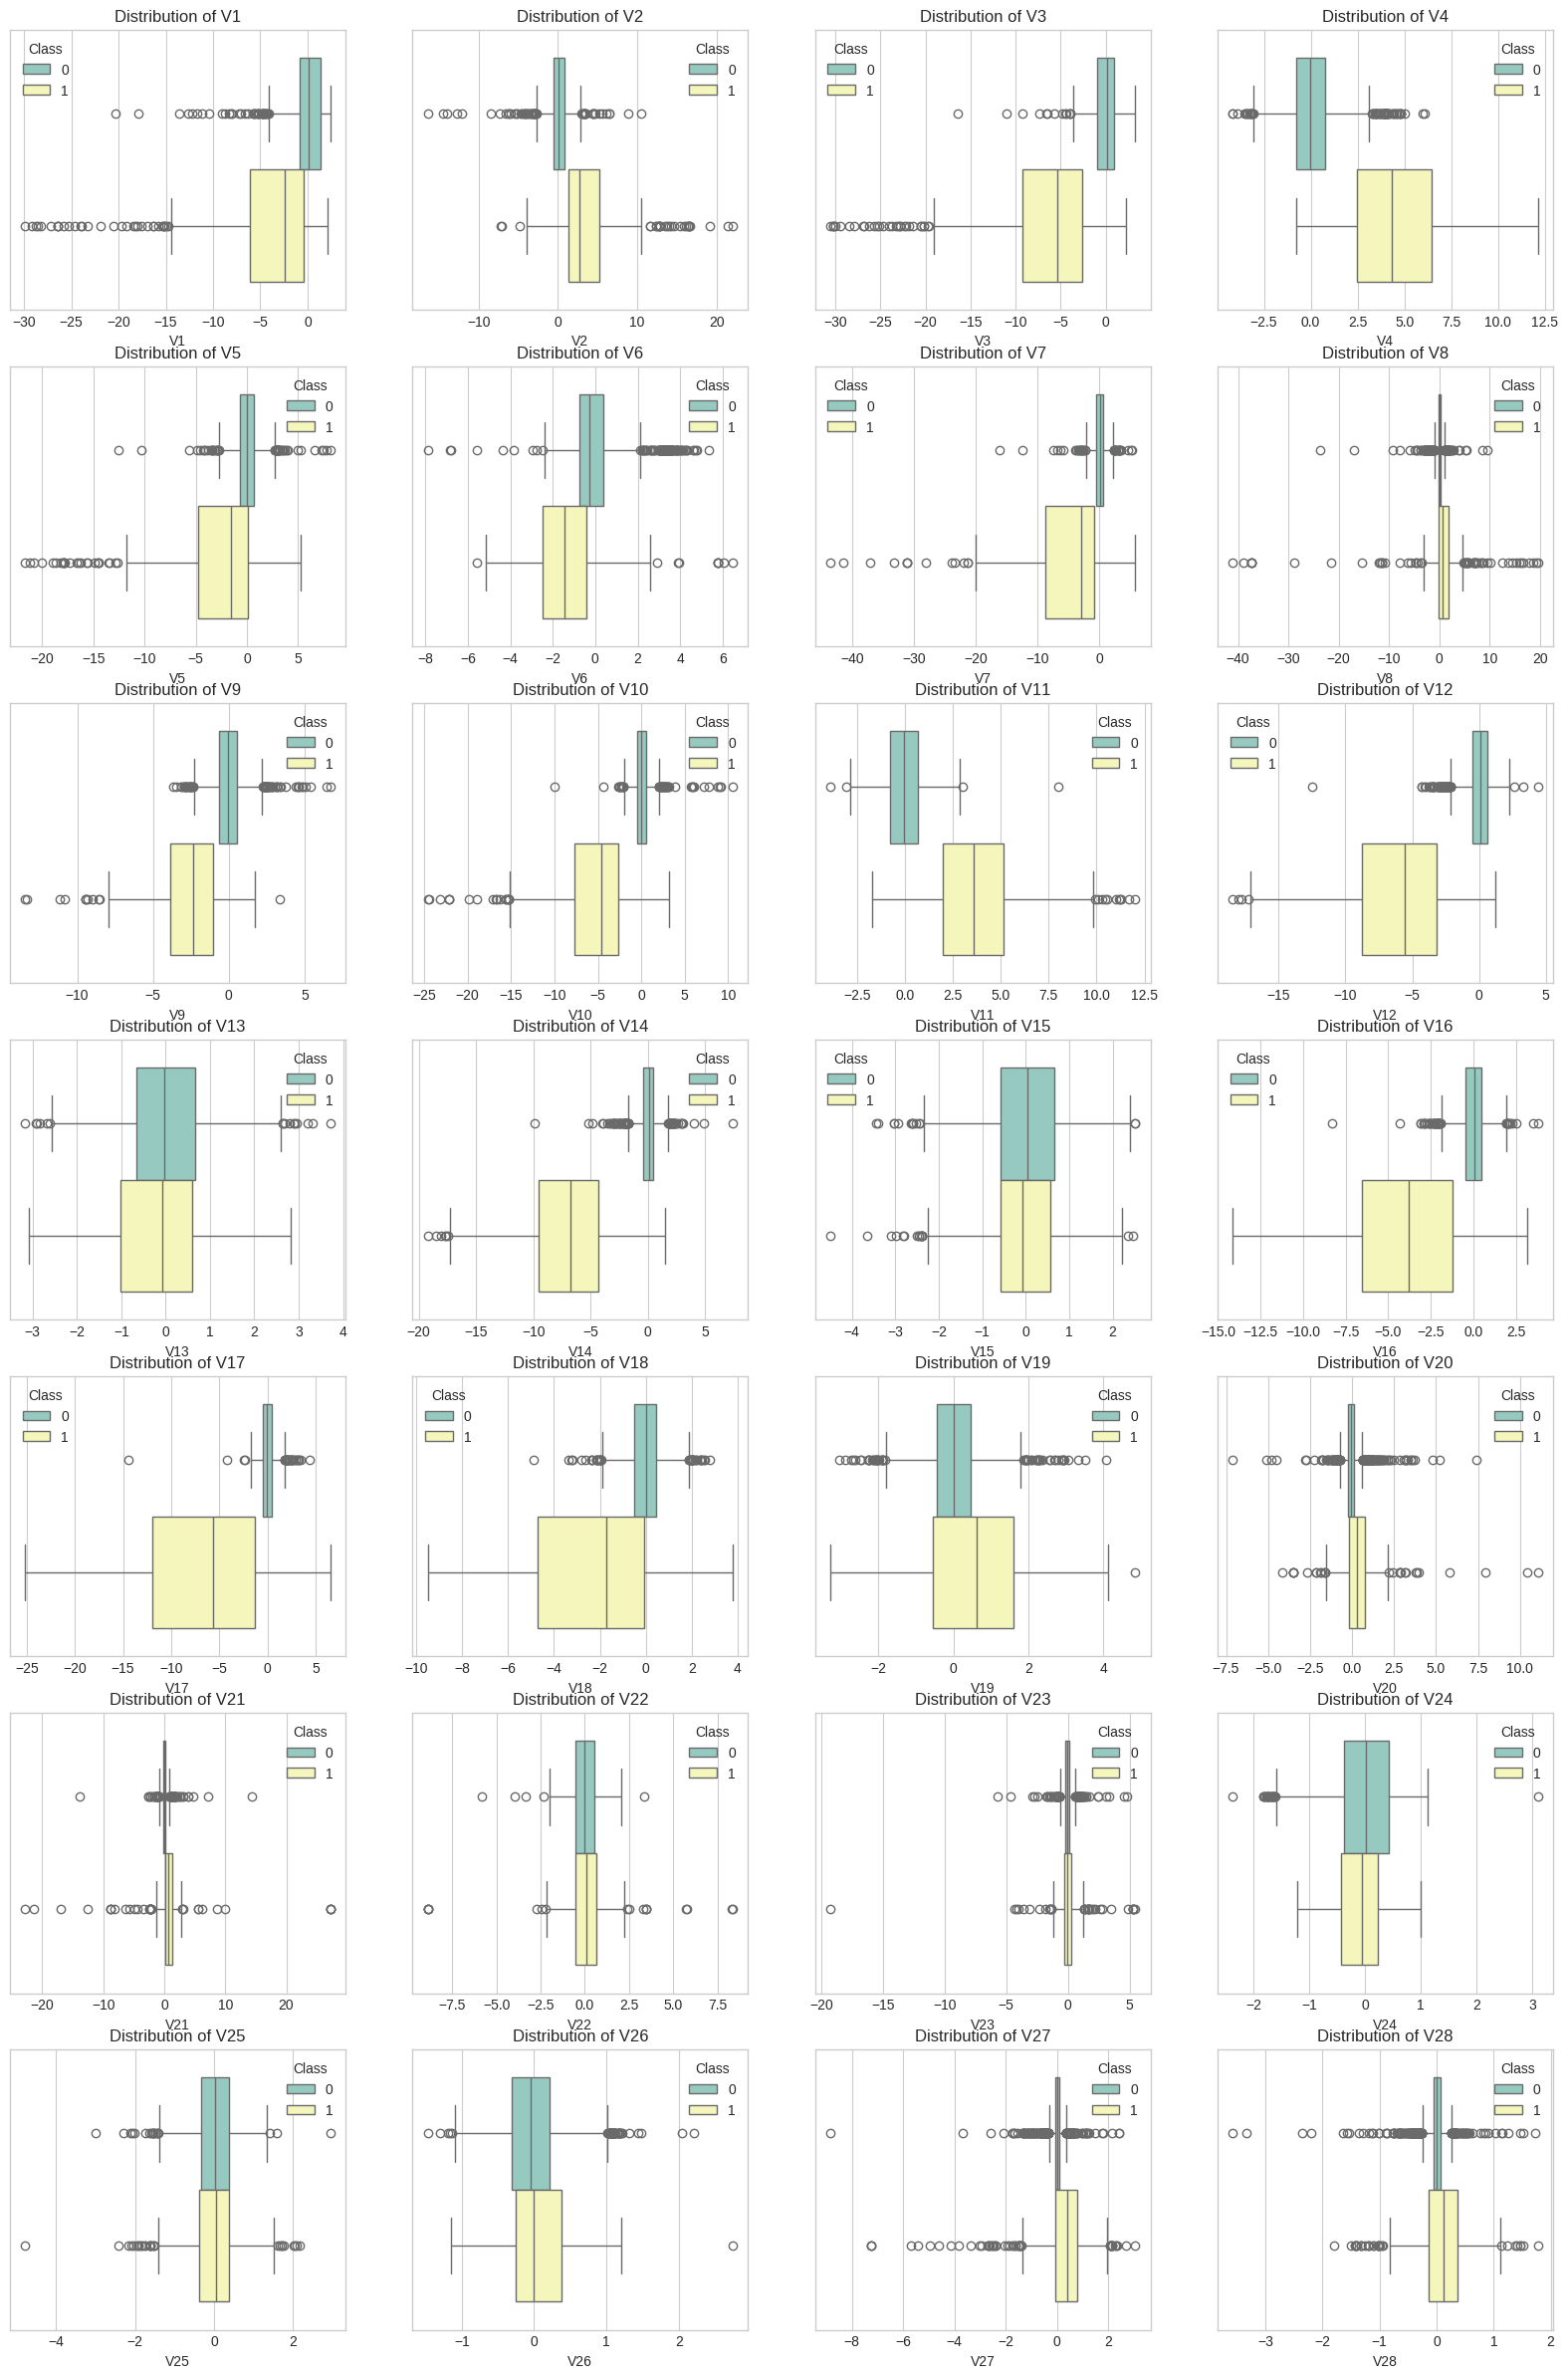

In [11]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Time', 'Class', 'Amount']).columns):
    sns.boxplot(data=sample, x=col, ax=ax, hue = 'Class')
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_boxplots_unclipped.png', bbox_inches='tight', facecolor='white')

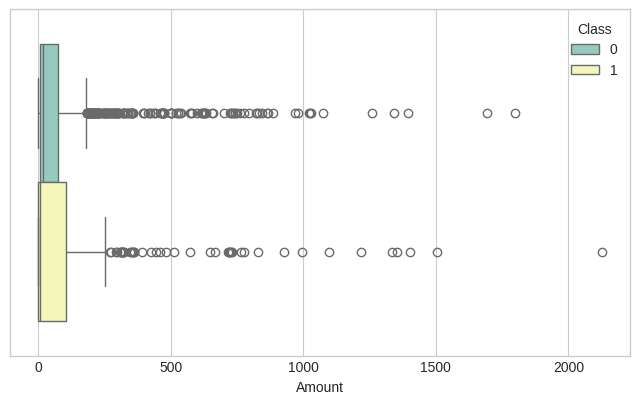

In [12]:
plt.figure(figsize=(8,4.5))
sns.boxplot(data=sample, x='Amount', hue = 'Class')
plt.savefig('../reports/figures/amount_boxplot_unclipped.png', bbox_inches='tight', facecolor='white')
plt.show()

The box plots show that some of the features are skewed, and some of the features have lots of outliers.

In [13]:
sample.drop(columns=['Time', 'Class']).skew()

V1       -3.925824
V2        2.274399
V3       -3.776309
V4        1.735013
V5       -3.692135
V6        0.388913
V7       -4.977781
V8       -6.081114
V9       -1.805281
V10      -3.241756
V11       2.108586
V12      -2.853096
V13       0.051746
V14      -2.541554
V15      -0.402760
V16      -2.808228
V17      -3.261829
V18      -2.361712
V19       0.631158
V20       3.177406
V21       4.310722
V22      -0.981371
V23      -7.949069
V24      -0.455221
V25      -0.638791
V26       0.546199
V27      -4.235627
V28      -1.956491
Amount    4.497849
dtype: float64

We can clip the outliers to see if the values given for skewness have been largely affected by outliers. We will use $Q_1 - 1.5 \times \text{IQR}$ for the lower bound, and $Q_3 + 1.5 \times \text{IQR}$ for the upper bound, given that those are the boundaries used for outliers in the box plots.

In [16]:
def clip_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return series.clip(lower_bound, upper_bound)

In [17]:
clipped_sample = sample.drop(columns=['Time', 'Class']).apply(clip_outliers).join(sample['Class'])
clipped_sample.skew()

V1       -0.855533
V2        0.362167
V3       -0.885775
V4        0.631632
V5       -0.260822
V6        0.183203
V7       -0.554045
V8        0.254943
V9       -0.376643
V10      -0.505824
V11       0.831160
V12      -0.864598
V13       0.026690
V14      -0.721575
V15      -0.262004
V16      -0.663423
V17      -0.423344
V18      -0.437551
V19       0.163110
V20       0.294439
V21       0.363938
V22      -0.032019
V23       0.087220
V24      -0.468513
V25      -0.194320
V26       0.312911
V27       0.215076
V28       0.029425
Amount    1.232144
Class     1.790372
dtype: float64

Now, the data is much less skewed, but we can examine what happened to the distributions.

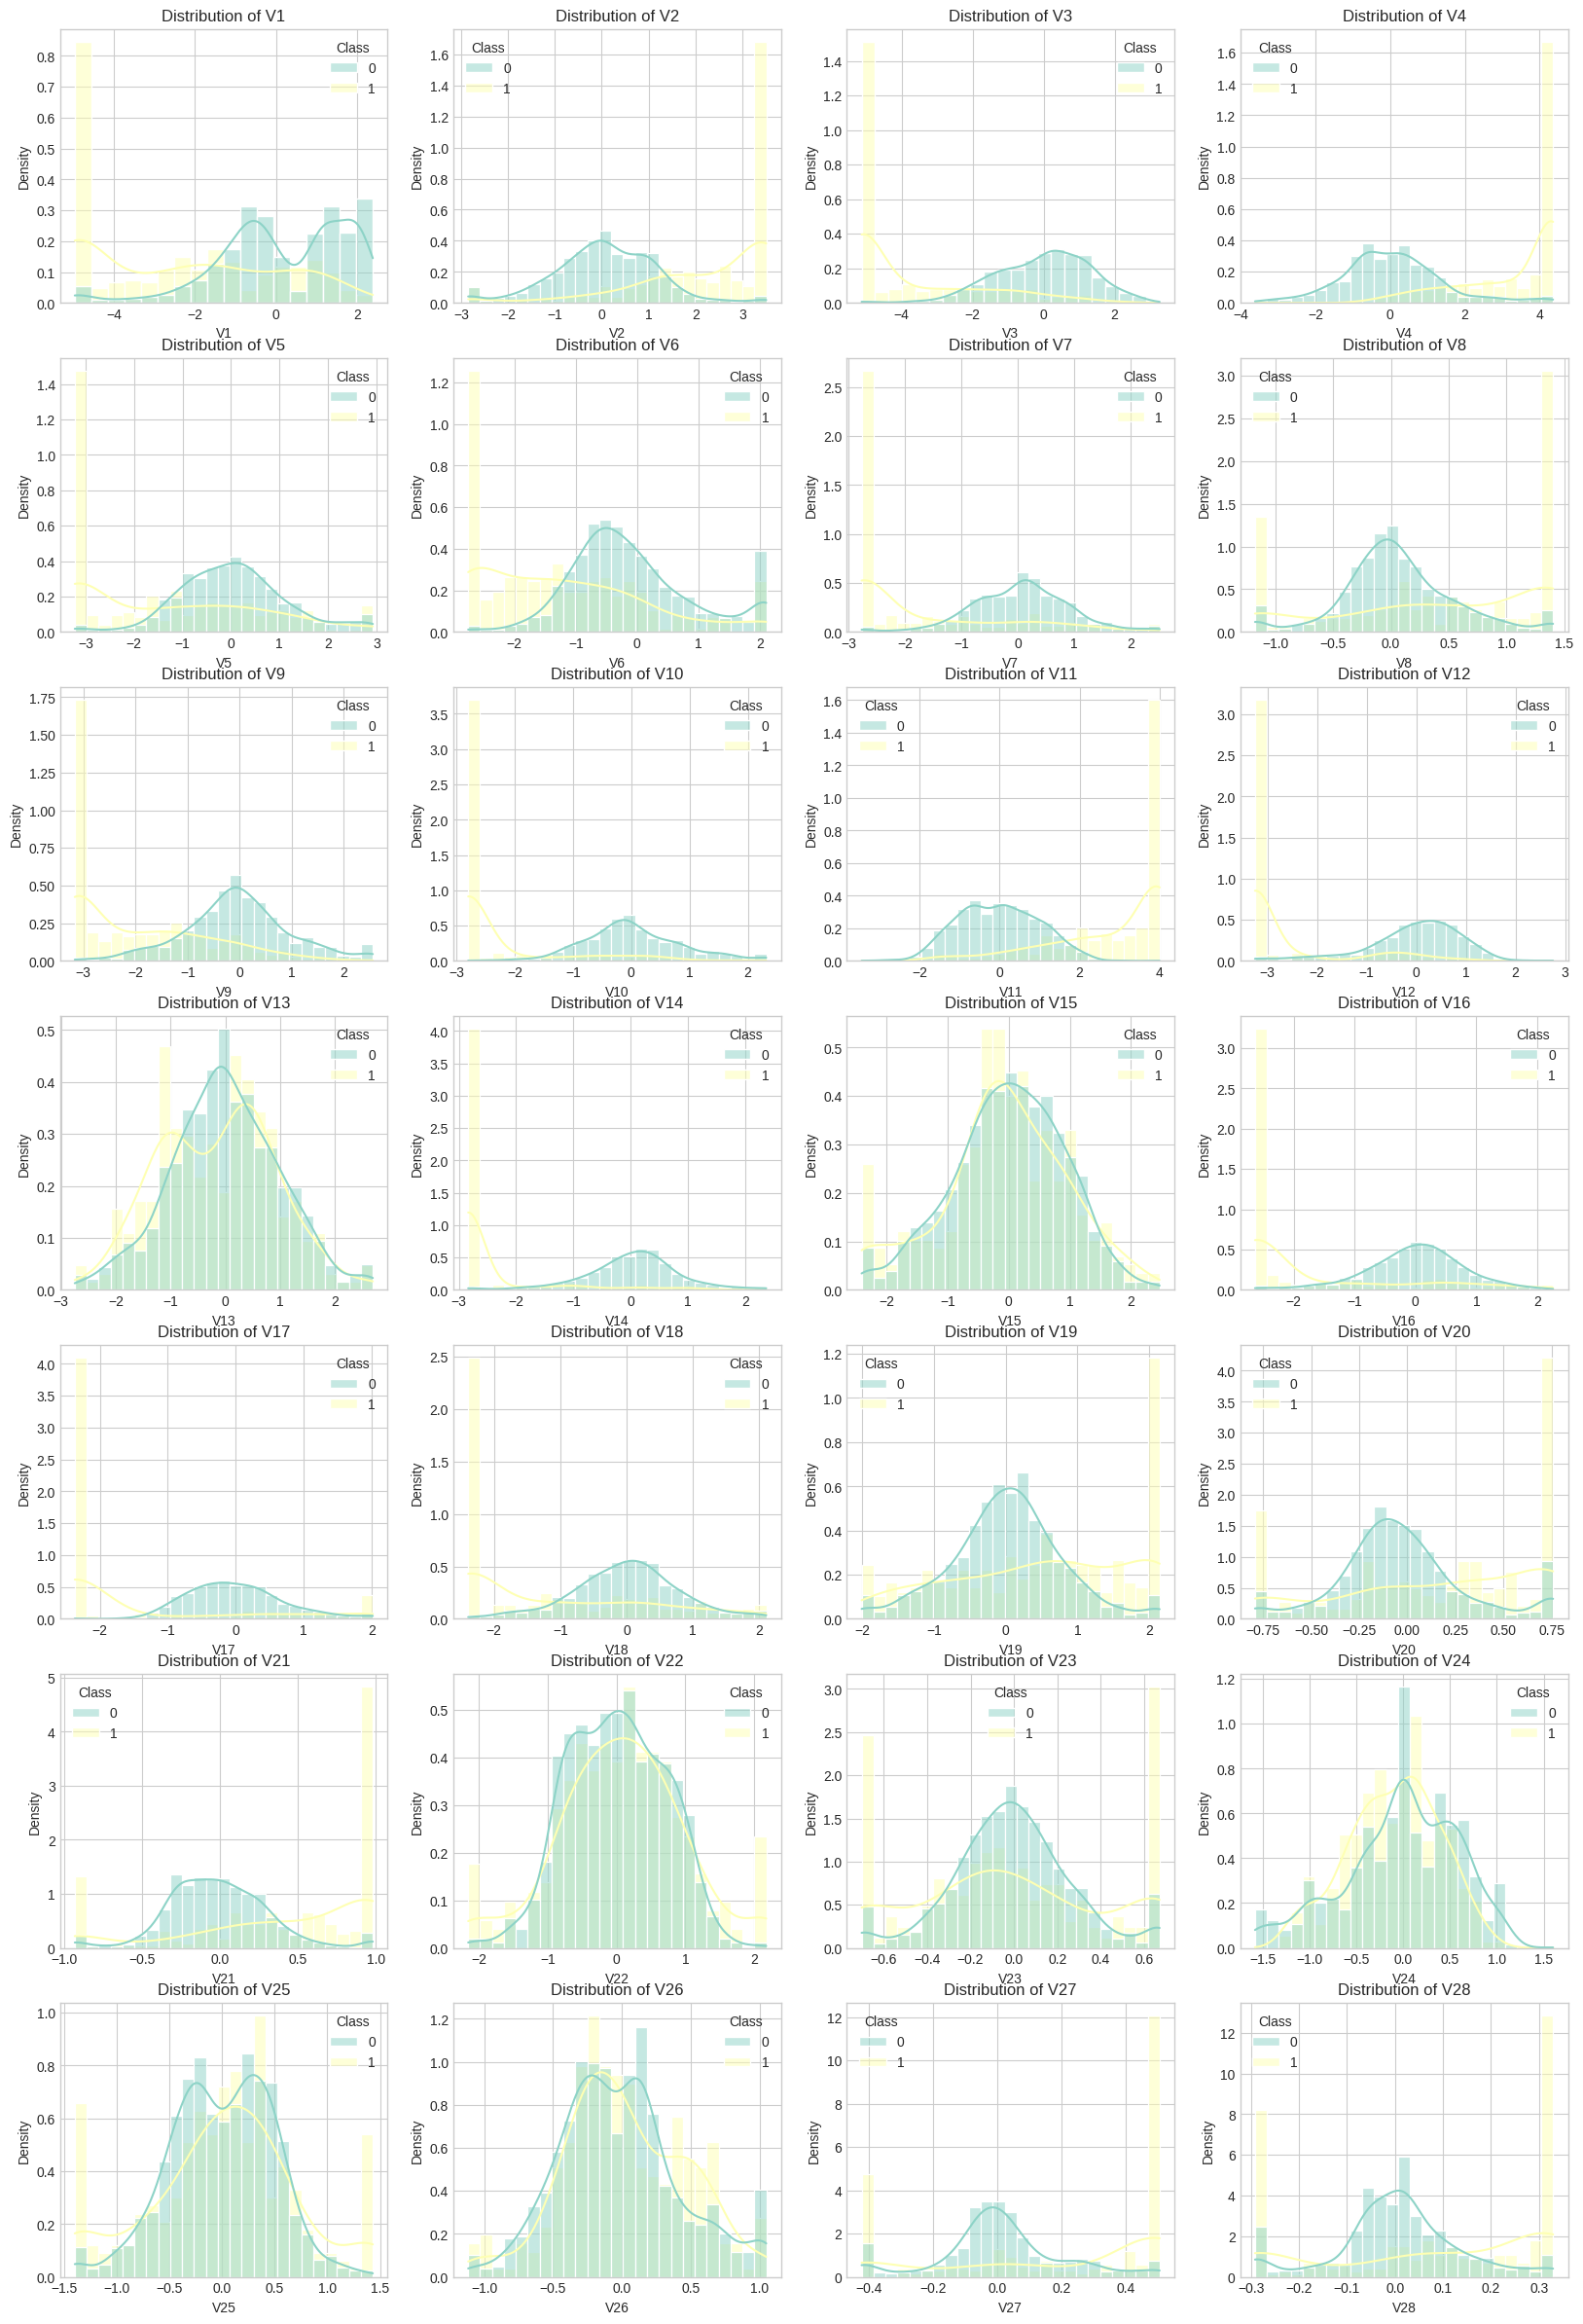

In [18]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Time', 'Class']).columns):
    sns.histplot(data=clipped_sample, x=col, kde=True, ax=ax, hue = 'Class', stat='density', common_norm=False)
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_distributions_clipped.png', bbox_inches='tight', facecolor='white')

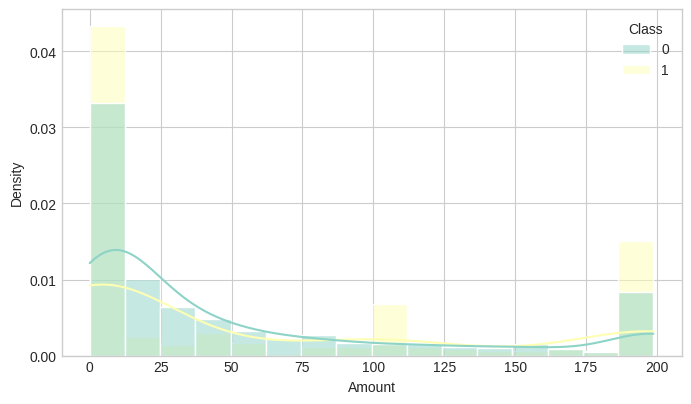

In [19]:
plt.figure(figsize=(8,4.5))
sns.histplot(data=clipped_sample, x='Amount', kde=True, hue = 'Class', stat='density', common_norm=False)
plt.savefig('../reports/figures/amount_distribution_clipped.png', bbox_inches='tight', facecolor='white')
plt.show()

After clipping the dataset, the boundary values that outliers were clipped to have a very high density, particularly for the positive cases, which suggests that the extreme values may be very important in predicting fraudulent transactions.

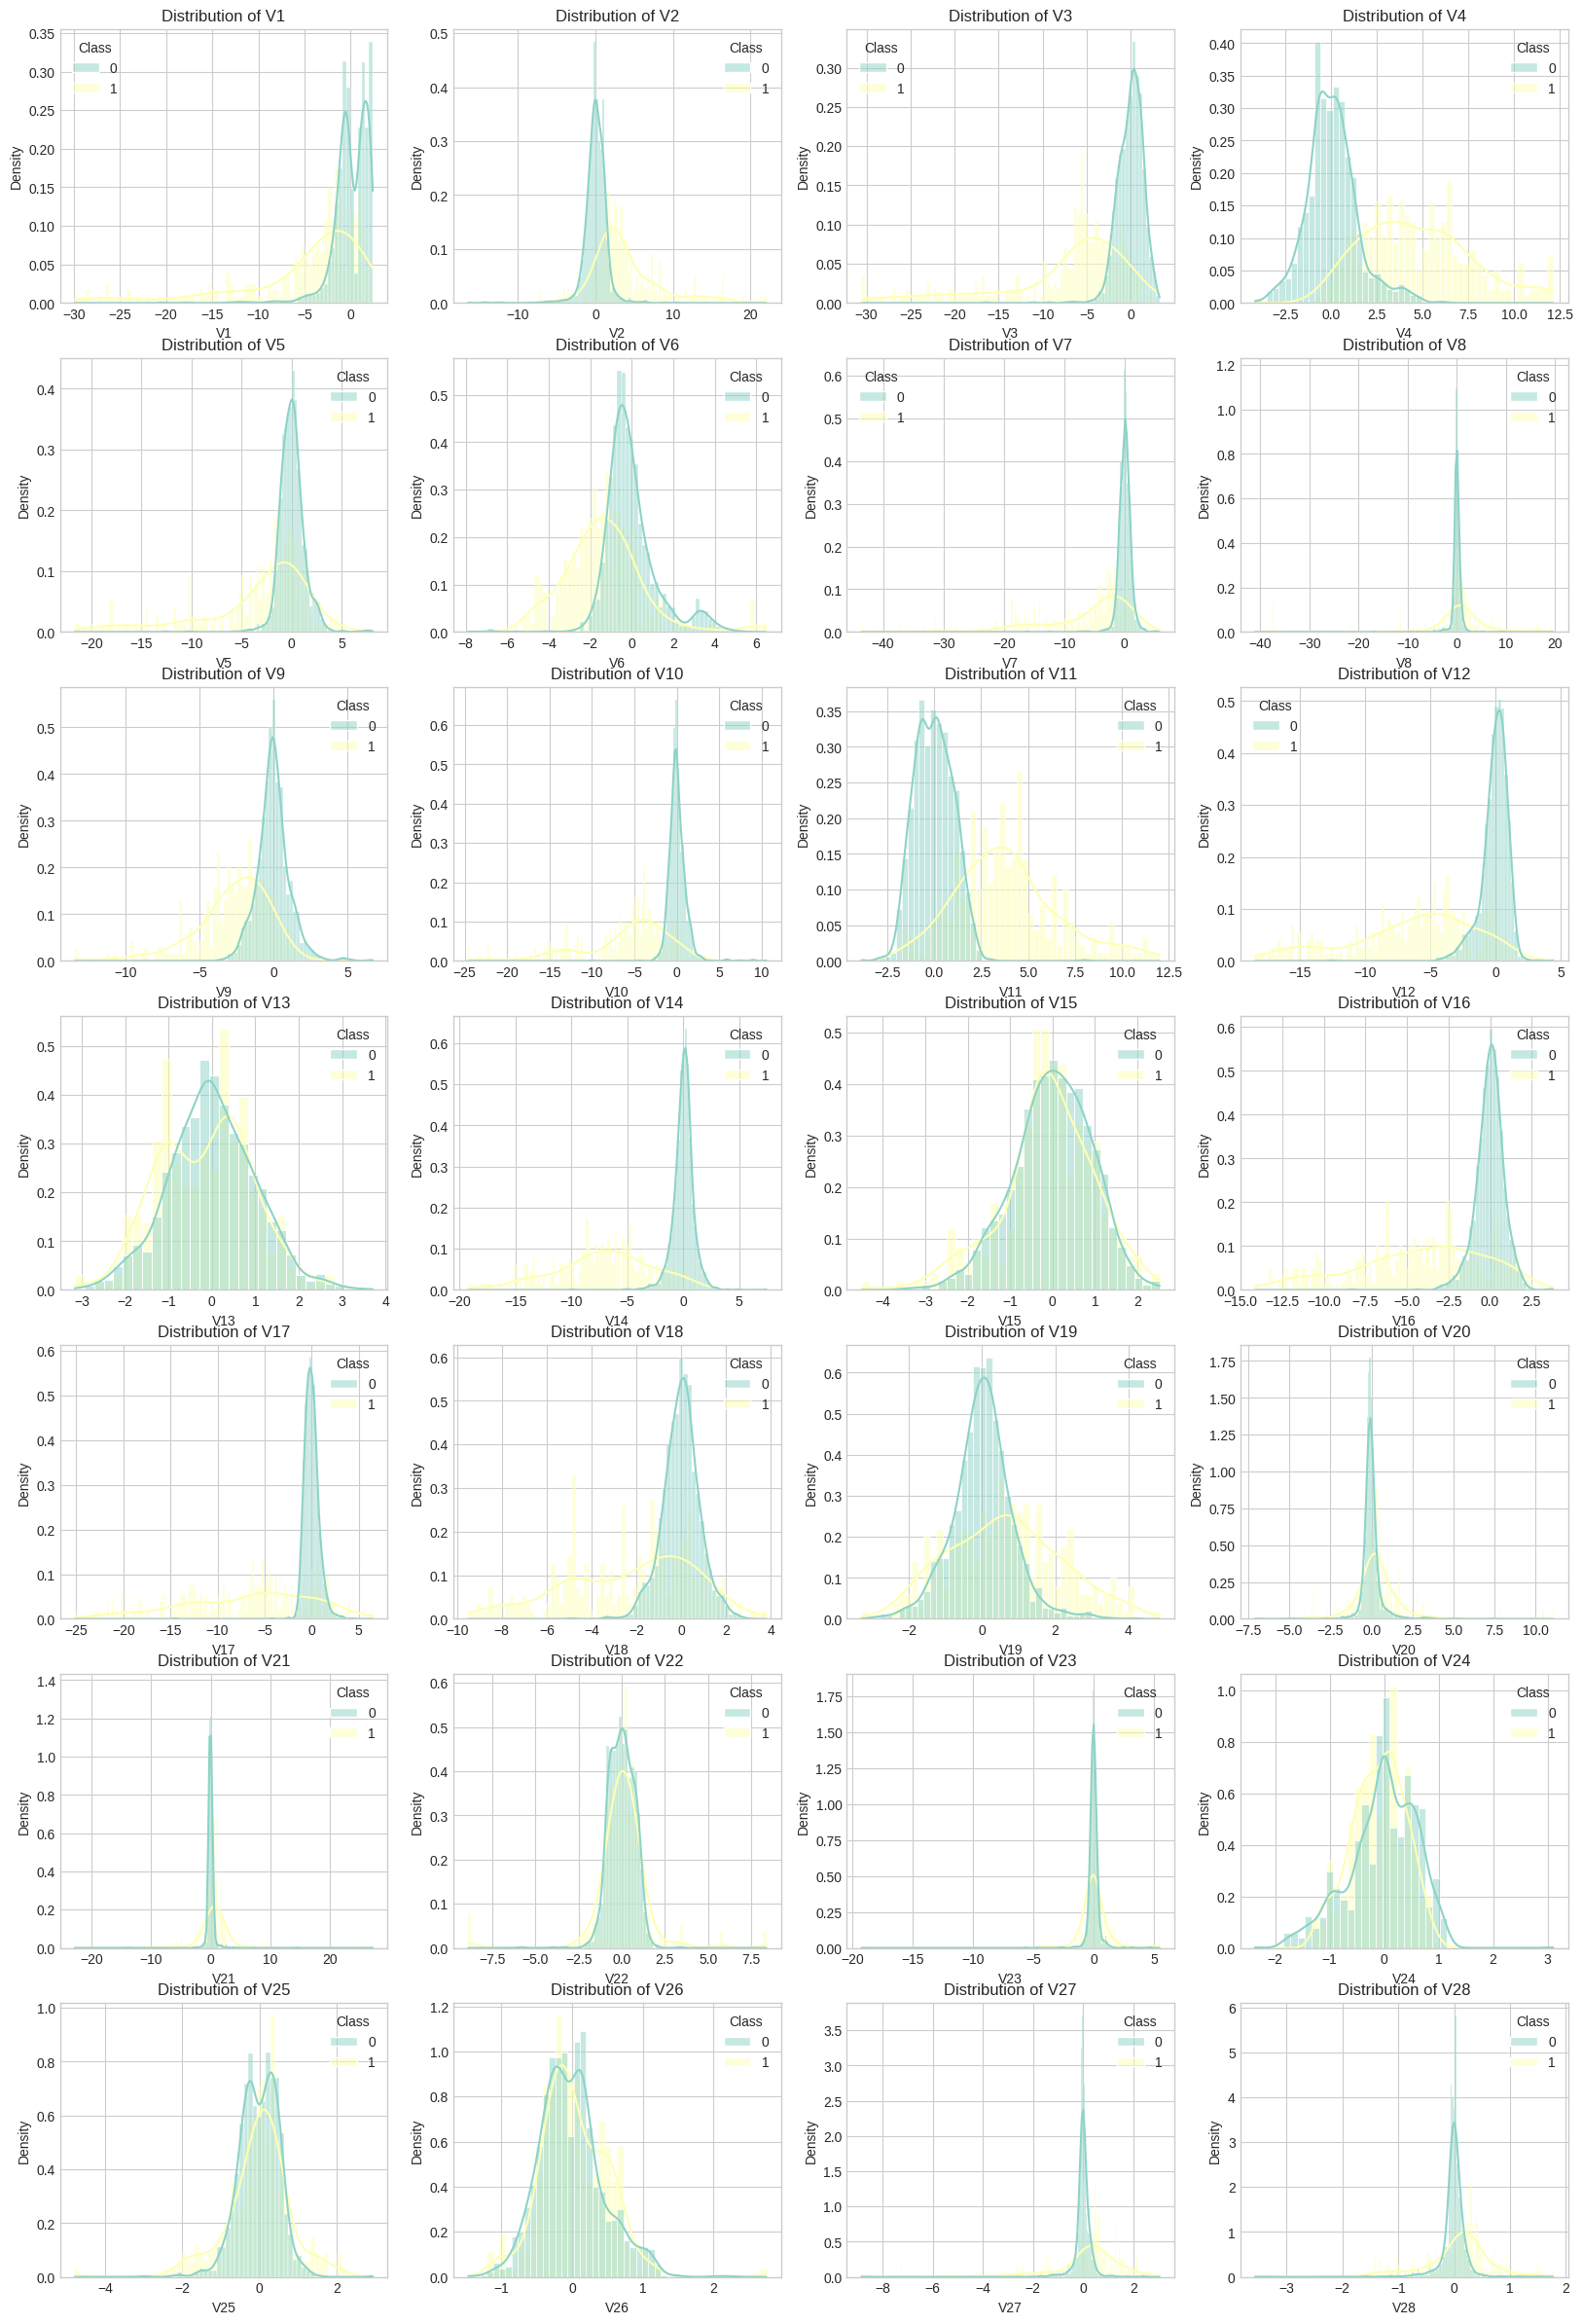

In [14]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Time', 'Class']).columns):
    sns.histplot(data=sample, x=col, kde=True, ax=ax, hue = 'Class', stat='density', common_norm=False)
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_distributions_unclipped.png', bbox_inches='tight', facecolor='white')

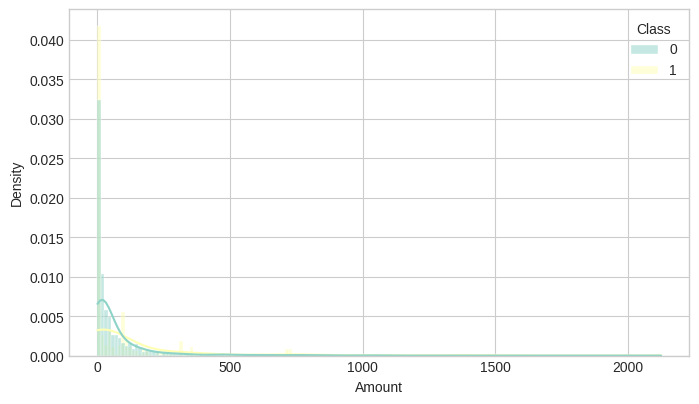

In [15]:
plt.figure(figsize=(8,4.5))
sns.histplot(data=sample, x='Amount', kde=True, hue = 'Class', stat='density', common_norm=False)
plt.savefig('../reports/figures/amount_distribution_unclipped.png', bbox_inches='tight', facecolor='white')
plt.show()

The distributions for some of the principal components are very similar for both positive and negative cases, however some of them seem to have some differences. Some seem to be wider for positive cases than for negative cases, so we can use Levene's test to compare variances. The peaks of the distributions are also quite different for some of the principal components, so we can use Mann-Whitney's U test to check for differences in central tendency.

In [21]:
levene_results = pd.DataFrame(columns = ['Feature', 'Statistic', 'p-value'])
for col in sample.drop(columns=['Time', 'Class']).columns:
    stat, p = sps.levene(sample_negative[col], sample_positive[col])
    levene_results = pd.concat([levene_results, pd.DataFrame({'Feature': [col], 'Statistic': [stat], 'p-value': [p]})], ignore_index=True)
levene_results['is_significant'] = levene_results['p-value'] < 0.05
levene_results

/tmp/ipykernel_11626/944224362.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  levene_results = pd.concat([levene_results, pd.DataFrame({'Feature': [col], 'Statistic': [stat], 'p-value': [p]})], ignore_index=True)


,Feature,Statistic,p-value,is_significant
0,V1,344.653131,1.980626e-70,True
1,V2,302.231487,1.282790e-62,True
2,V3,583.197980,1.363952e-111,True
3,V4,363.827905,6.581209e-74,True
4,V5,500.412897,8.345395e-98,True
5,V6,64.443560,1.794055e-15,True
6,V7,639.524547,1.074279e-120,True
7,V8,246.677530,3.881978e-52,True
8,V9,285.097145,2.040134e-59,True
9,V10,712.443846,3.620340e-132,True


The only feature that has no significant difference between the variances of positive and negative cases is `V26`

In [23]:
mwu_results = pd.DataFrame(columns = ['Feature', 'Statistic', 'p-value'])
for col in sample.drop(columns=['Time', 'Class']).columns:
    stat, p = sps.mannwhitneyu(sample_negative[col], sample_positive[col])
    mwu_results = pd.concat([mwu_results, pd.DataFrame({'Feature': [col], 'Statistic': [stat], 'p-value': [p]})], ignore_index=True)
mwu_results['is_significant'] = mwu_results['p-value'] < 0.05
mwu_results

/tmp/ipykernel_11626/469014905.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mwu_results = pd.concat([mwu_results, pd.DataFrame({'Feature': [col], 'Statistic': [stat], 'p-value': [p]})], ignore_index=True)


,Feature,Statistic,p-value,is_significant
0,V1,351798.0,5.570558e-63,True
1,V2,54899.0,1.326760e-91,True
2,V3,399878.0,1.408981e-114,True
3,V4,26206.0,5.060675e-126,True
4,V5,316427.0,5.719013e-35,True
5,V6,331939.0,3.233233e-46,True
6,V7,364776.0,2.264029e-75,True
7,V8,148614.0,7.704351e-18,True
8,V9,375833.0,7.979776e-87,True
9,V10,402627.0,5.338506e-118,True


Given that our data has unequal variance between positive and negative cases, the results of the Mann-Whitney's U test only tells us that the distributions differ, but we can compare medians and variances to check where the differences lie.

In [34]:
def percentage_change(old, new):
    try:
        return ((new - old) / abs(old)) * 100
    except ZeroDivisionError:
        return math.inf

In [36]:
differences = pd.concat([sample_negative.drop(columns=['Time', 'Class']).var(), 
           sample_positive.drop(columns=['Time', 'Class']).var(),
           sample_negative.drop(columns=['Time', 'Class']).median(),
           sample_positive.drop(columns=['Time', 'Class']).median()], axis=1, keys=['Negative Variance', 'Positive Variance', 'Negative Median', 'Positive Median'])

differences['Variance % Change'] = differences.apply(lambda row: percentage_change(row['Negative Variance'], row['Positive Variance']), axis=1)
differences['Median % Change'] = differences.apply(lambda row: percentage_change(row['Negative Median'], row['Positive Median']), axis=1)

differences

,Negative Variance,Positive Variance,Negative Median,Positive Median,Variance % Change,Median % Change
V1,3.840990,49.504533,0.073562,-2.434004,1188.848167,-3408.758171
V2,2.379795,19.418688,0.049789,2.720472,715.981491,5364.038074
V3,2.146793,54.501197,0.140262,-5.399730,2438.726634,-3949.736659
V4,1.935274,8.697522,-0.008228,4.311234,349.420707,52496.596803
V5,1.678088,29.236047,0.005215,-1.566487,1642.223995,-30139.836584
V6,1.603513,3.702047,-0.294489,-1.430289,130.871020,-385.685150
V7,1.231250,60.053545,0.086326,-3.028013,4777.444607,-3607.643136
V8,1.283936,54.389971,0.013645,0.555945,4136.191151,3974.436046
V9,1.216025,6.286511,-0.046754,-2.329629,416.972147,-4882.774465
V10,1.195744,26.114724,-0.058673,-4.594952,2083.972123,-7731.465534


Here, we can see that for the majority of the features, both variance and median are very different for positive and negative cases.

In [25]:
mwu_results[~mwu_results['is_significant']]['Feature']

14    V15
21    V22
22    V23
24    V25
25    V26
Name: Feature, dtype: object

Since `V26` shows no significant difference in both median and variance between the positive and negative cases, it suggests that on its own, it may be a bad predictor of whether a transaction is fraudulent or not.

Although the principal components are independent of each other and have no correlation between them, there may be useful correlations that we see within the classes.

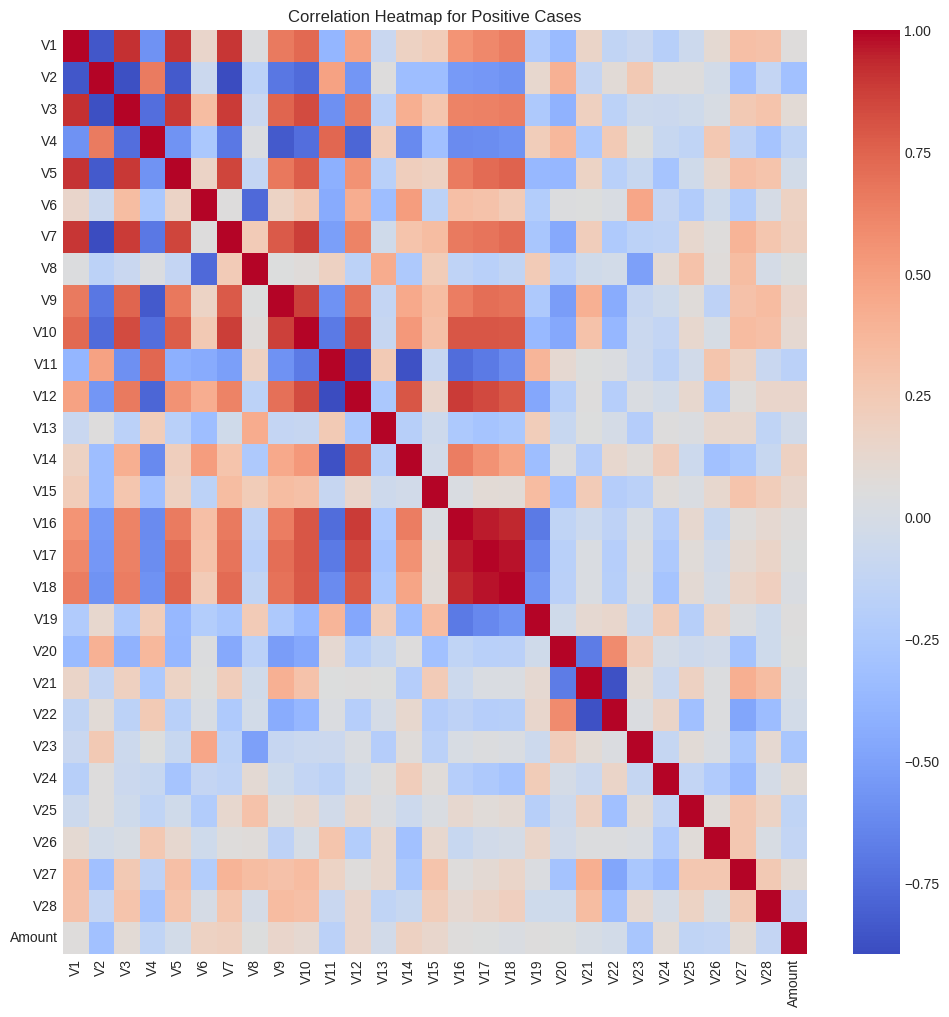

In [47]:
plt.figure(figsize=(12,12))
plt.title('Correlation Heatmap for Positive Cases')
sns.heatmap(sample_positive.drop(columns=['Time', 'Class']).corr(), cmap='coolwarm')
plt.savefig('../reports/figures/correlation_heatmap_positive.png', bbox_inches='tight', facecolor='white')
plt.show()

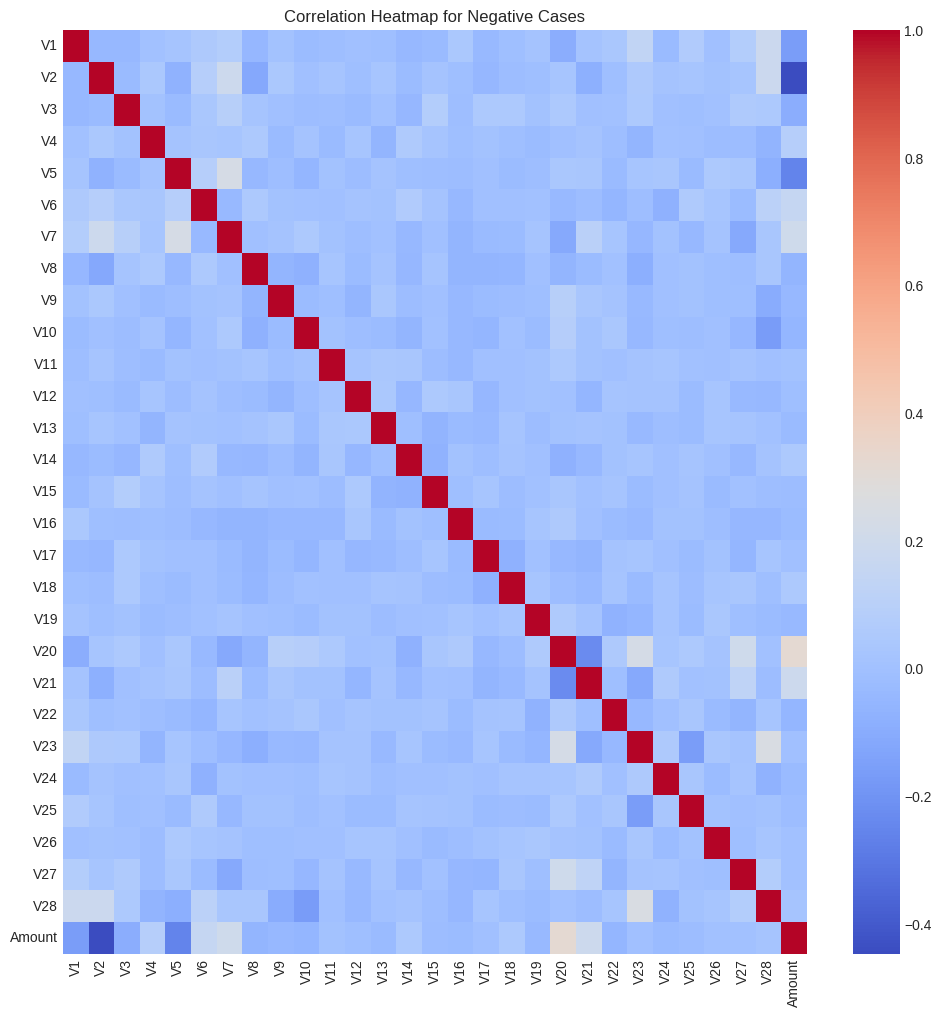

In [46]:
plt.figure(figsize=(12,12))
plt.title('Correlation Heatmap for Negative Cases')
sns.heatmap(sample_negative.drop(columns=['Time', 'Class']).corr(), cmap='coolwarm')
plt.savefig('../reports/figures/correlation_heatmap_negative.png', bbox_inches='tight', facecolor='white')
plt.show()

We can immediately see that the features for the negative cases are far less correlated than the features for the positive cases.

## Key Takeaways
- The data has a lot of outliers, and removing them may reduce predictive power, as the outliers seemed to be more pronounced with the positive cases.
- The data is heavily imbalanced between positive and negative cases, so synthetic data generation may be necessary for the training data.
- There are combinations of features that are correlated with each other for the positive cases, so it is important to use a model that can deal with these interactions between features.